In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize


In [3]:
plt.rcParams["figure.dpi"] = 150
plt.rcParams["text.usetex"] = True
plt.rcParams["font.size"] = 12


# matplotlib.rcParams['mathtext.fontset'] = 'stix'
# matplotlib.rcParams['font.family'] = 'Computer Modern'


plt.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs
%config InlineBackend.figure_format = 'retina'
#plt.rcParams['axes.grid'] = True

In [4]:
def line(x, b):
    return -x + b

Focal length: $153.08015961568327 +/- 0.5105678144668129 mm
-8.664626120203752e-07 -1.1997892275550064


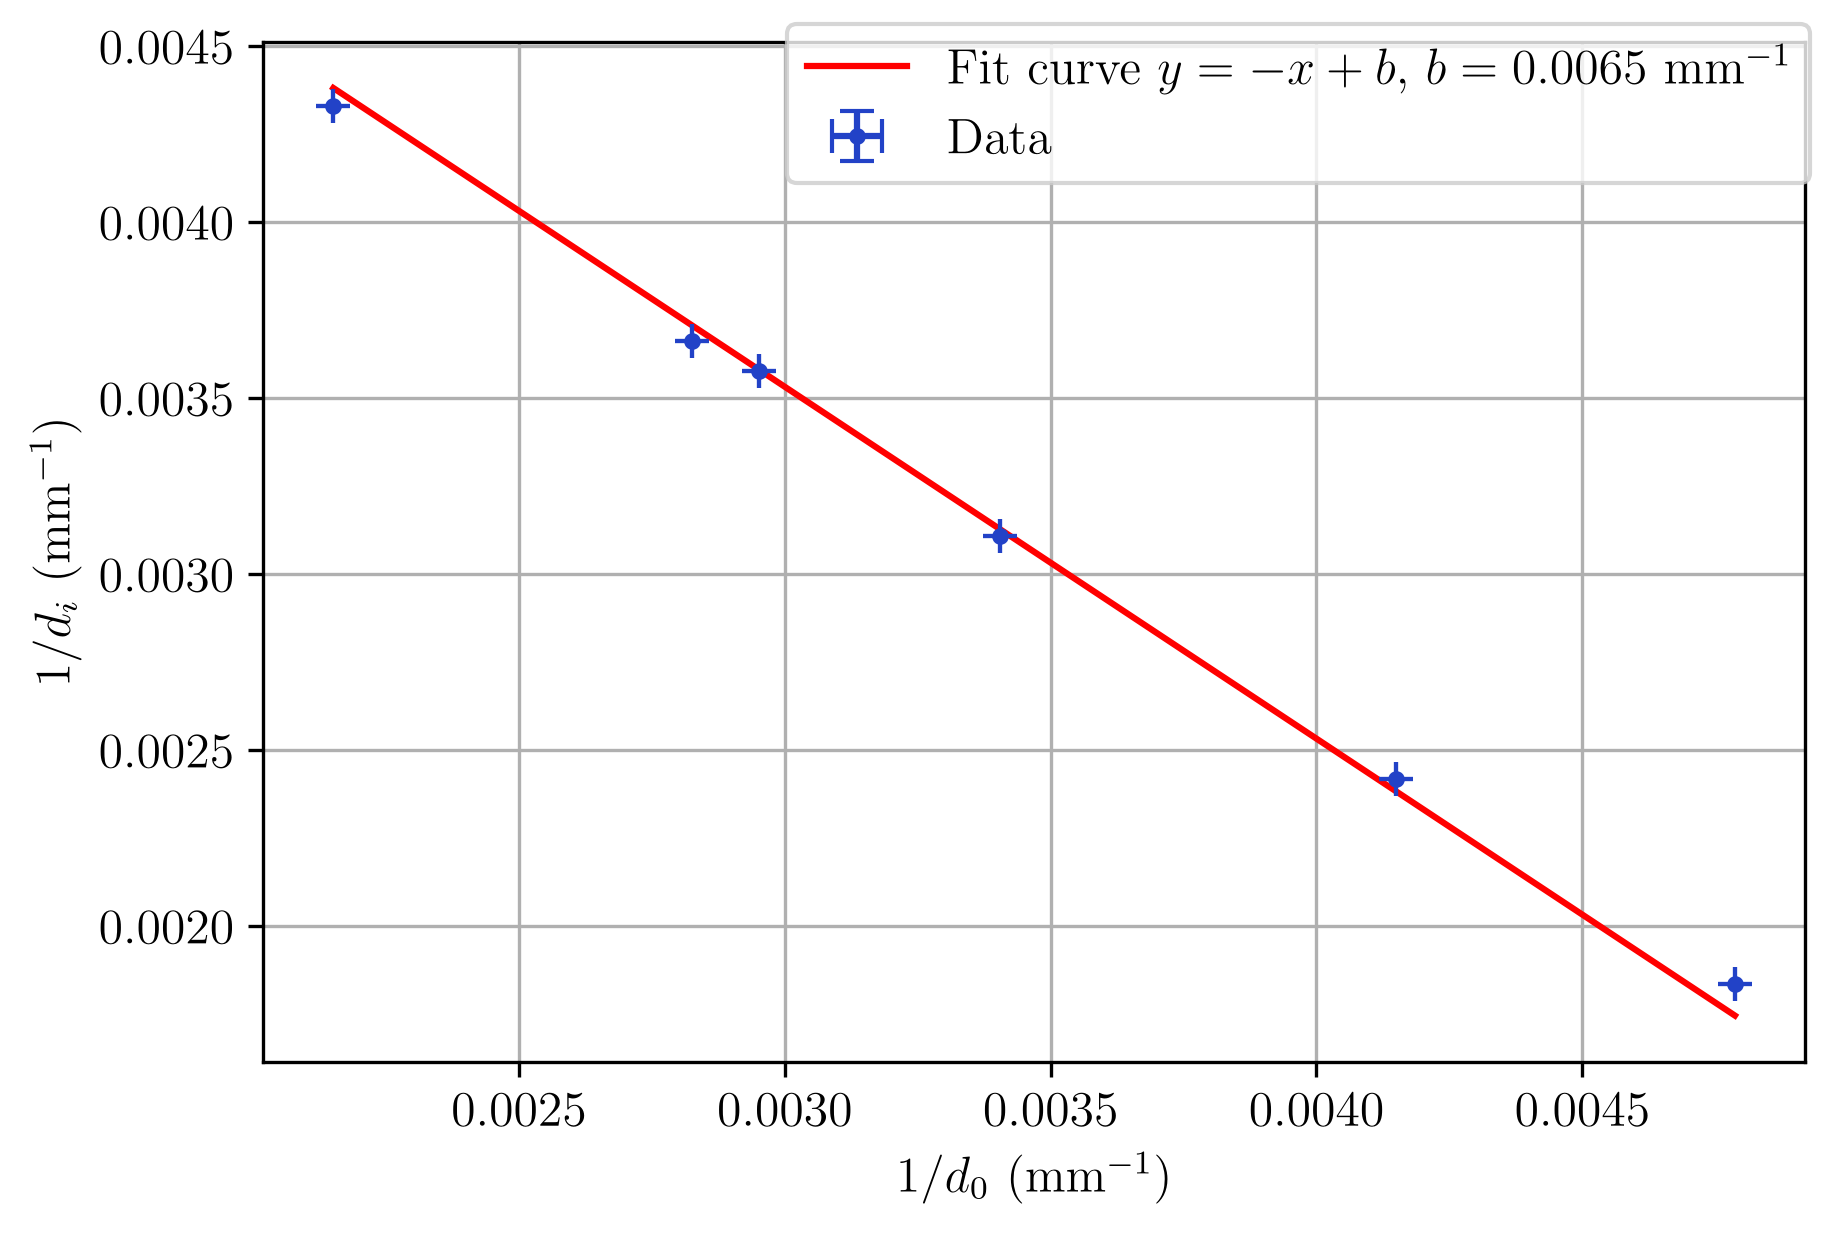

In [25]:
d_obj = np.array([208.9, 241.0, 293.7, 338.8, 354.0, 464.9])
d_obj_err = np.ones(6) * 1.1

d_img = np.array([545.2, 413.8, 321.7, 279.6, 273.1, 231.0])
d_img_err = np.ones(6) * 1.1

h_img = np.array([38.72, 24.88, 15.90, 12.36, 11.78, 7.56])
h_img_err = np.ones(6) * 0.05

#ERRORS FOR SIGMA
popt, pcov = scipy.optimize.curve_fit(line, 1 / d_obj, 1 / d_img)

b = popt[0]
b_err = np.sqrt(pcov[0][0])

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")

#PROOPOGATE ERRORS
ax.errorbar(1 / d_obj, 1 / d_img, 0, 0, fmt = 'o', markersize = 3, capsize = 4, color = 'xkcd:blue blue', zorder=10, label = "Data")


print(f"Focal length: ${1/b} +/- {np.abs(b_err / (b**2))} mm")


cov_xy = (1/(len(d_obj)-1)) * np.sum(((1/d_obj) - np.mean(1/d_obj)) * ((1/d_img) - np.mean(1/d_img)))

rho_xy = cov_xy / (np.std(1/d_obj) * np.std(1/d_img))

print(cov_xy, rho_xy)


ax.set_xlabel(r"$1 / d_0$ (mm$^{-1}$)")
ax.set_ylabel(r"$1 / d_i$ (mm$^{-1}$)")

x_vals = np.linspace(np.min(1/d_obj), np.max(1/d_obj), 100)
ax.plot(x_vals, line(x_vals, b), color = 'red', label = rf"Fit curve $y = -x + b$, $b = {b:0.4f}$ mm$^{{-1}}$")

fig.legend()
ax.grid()

fig.savefig("exp3_data.png", dpi=400)